In [1]:
import torch
from torch_geometric.data import HeteroData
import networkx as nx
from typing import Tuple, Dict, Any
from tqdm import tqdm
import copy


import os
import sys
try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()
sys.path.append(os.path.dirname(base_dir))
from utils.graph_utils import load_graph, save_graph
from data_processing.patient_network_prep import convert_to_hetero_data, process_and_save

/opt/anaconda3/envs/firegnn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Prepare HeteroData

In [5]:
# load graph
geo_ecdf = load_graph('./data/GEO/GSE33000_ad_hd/G_geo_ReversedHybrid_ecdf.pkl')
geo_logfc = load_graph('./data/GEO/GSE33000_ad_hd/G_geo_ReversedHybrid_logfc.pkl')
adni_ecdf = load_graph("./data/ADNI/G_adni_ReversedHybrid_ecdf.pkl")

Loaded graph from ./data/GEO/GSE33000_ad_hd/G_geo_ReversedHybrid_ecdf.pkl: 8287 nodes, 155702 edges
Loaded graph from ./data/GEO/GSE33000_ad_hd/G_geo_ReversedHybrid_logfc.pkl: 8287 nodes, 225558 edges
Loaded graph from ./data/ADNI/G_adni_ReversedHybrid_ecdf.pkl: 8275 nodes, 71780 edges


In [6]:
adni_ecdf_data, adni_ecdf_nodemappings = convert_to_hetero_data(adni_ecdf)
geo_ecdf_data, geo_ecdf_nodemappings = convert_to_hetero_data(geo_ecdf)
geo_logfc_data, geo_logfc_nodemappings = convert_to_hetero_data(geo_logfc)

Starting conversion from NetworkX to HeteroData...


/Users/yuxiaoxuan/master_thesis/FireGNN/utils/graph_prep.py:93: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1719361045918/work/torch/csrc/utils/tensor_new.cpp:277.)
  patient_x = torch.tensor([G.nodes[pid]['x'] for pid in p_ids], dtype=torch.float)


HeteroData created: 25 node types, 827 edge types.
Starting conversion from NetworkX to HeteroData...
HeteroData created: 25 node types, 827 edge types.
Starting conversion from NetworkX to HeteroData...
HeteroData created: 25 node types, 827 edge types.


In [7]:
geo_ecdf_data.node_types

['Patient',
 'Gene',
 'Abundance',
 'BiologicalProcess',
 'Activity',
 'Pathology',
 'MicroRna',
 'Protein',
 'Rna',
 'Translocation',
 'Reaction',
 'Degradation',
 'CellSecretion',
 'CellSurfaceExpression',
 'Complex',
 'Composite',
 'Products',
 'Reactants',
 'FusionProtein',
 'Pmod',
 'Fragment',
 'Variant',
 'Location',
 'FromLocation',
 'ToLocation']

### Plot Model performance

In [2]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
def extract_metrics(root_dir):
    """
    Walks through the directory structure:
    root_dir / process_method / dataset / scoring / model / metrics.json
    """
    data_list = []
    
    # We expect the root_dir to contain ['ADKG', 'HealthyKG', 'merge', 'hybrid']
    for process_method in os.listdir(root_dir):
        pm_path = os.path.join(root_dir, process_method)
        if not os.path.isdir(pm_path): continue
        
        for dataset in os.listdir(pm_path):
            ds_path = os.path.join(pm_path, dataset)
            if not os.path.isdir(ds_path): continue
            
            for scoring in os.listdir(ds_path):
                sc_path = os.path.join(ds_path, scoring)
                if not os.path.isdir(sc_path): continue
                
                for model_type in os.listdir(sc_path):
                    m_path = os.path.join(sc_path, model_type)
                    metrics_file = os.path.join(m_path, 'metrics.json')
                    
                    if os.path.exists(metrics_file):
                        with open(metrics_file, 'r') as f:
                            metrics = json.load(f)
                        
                        # Extract the specific classification metrics
                        cls_metrics = metrics.get("test_classification", {})
                        
                        data_list.append({
                            "Method": process_method,
                            "Dataset": dataset,
                            "Scoring": scoring,
                            "Model": model_type,
                            "Accuracy": cls_metrics.get("acc"),
                            "F1": cls_metrics.get("f1_macro"),
                            "AUROC": cls_metrics.get("auroc"),
                            "AUPRC": cls_metrics.get("auprc"),
                            "Hits@10": metrics.get("test_link")
                        })
    
    return pd.DataFrame(data_list)

import matplotlib.pyplot as plt
import seaborn as sns

def plot_grouped_performance(df, metric_name="AUROC"):
    """
    Groups by Method on the X-axis.
    Each group contains bars for different Dataset + Scoring combinations.
    """
    # 1. Create a combined column for the legend/bars
    # This turns 'adni' and 'ecdf' into 'adni - ecdf'
    df['Condition'] = df['Dataset'] + " (" + df['Scoring'] + ")"
    
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    # 2. Plot
    # x="Method": Groups are ADKG, HealthyKG, merge, etc.
    # hue="Condition": Individual bars for adni(ecdf), geo(ecdf), etc.
    ax = sns.barplot(
        data=df, 
        x="Method", 
        y=metric_name, 
        hue="Condition", 
        palette="muted",
        edgecolor="black"
    )
    
    # 3. Formatting
    plt.title(f"Performance Comparison by Network Construction Method and Dataset ({metric_name})", fontsize=16, pad=20)
    plt.ylabel(metric_name, fontsize=12)
    plt.xlabel("Network Construction Method", fontsize=12)
    
    # Fix legend position so it doesn't cover bars
    plt.legend(title="Dataset (Scoring)", bbox_to_anchor=(1.02, 1), loc='upper left')
    
    # Optional: Add value labels on top of bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

    plt.tight_layout()
    plt.show()

In [4]:
results_df = extract_metrics('../results/BaseHeteroKg')
results_df

,Method,Dataset,Scoring,Model,Accuracy,F1,AUROC,AUPRC,Hits@10
0,merge,geo,ecdf,gat,0.676056,0.641650,0.717199,0.789398,0.274156
1,merge,adni,ecdf,gat,0.492754,0.353760,0.518487,0.542329,0.215872
2,ADKG,geo,ecdf,gat,0.788732,0.761478,0.866135,0.935512,0.252404
3,ADKG,adni,ecdf,gat,0.507246,0.336538,0.440336,0.460051,0.259010
4,HealthyKG,geo,ecdf,gat,0.760563,0.744117,0.844415,0.871776,0.634608
5,HealthyKG,adni,ecdf,gat,0.492754,0.470975,0.545378,0.533516,0.403750
6,hybrid,geo,ecdf,gat,0.985915,0.984420,0.998227,0.999132,0.512465
7,hybrid,geo,logfc,gat,0.957746,0.953259,0.985816,0.992929,0.430194
8,hybrid,adni,ecdf,gat,0.797101,0.789634,1.000000,1.000000,0.378720


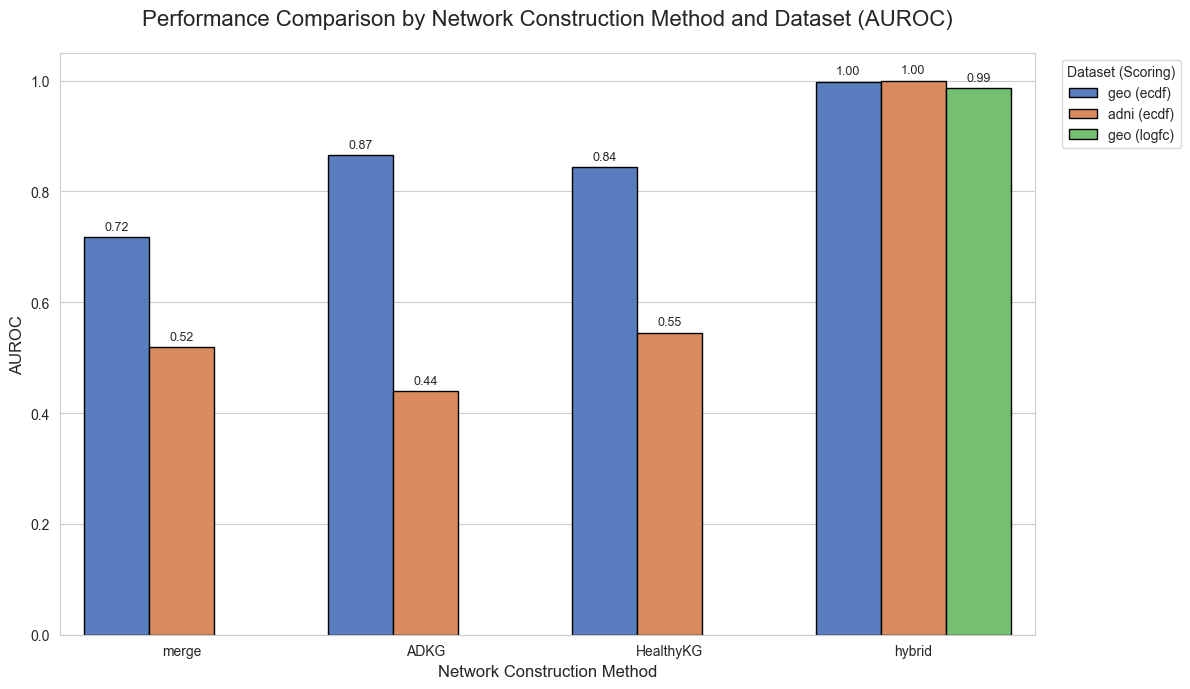

In [5]:
plot_grouped_performance(results_df, metric_name="AUROC")

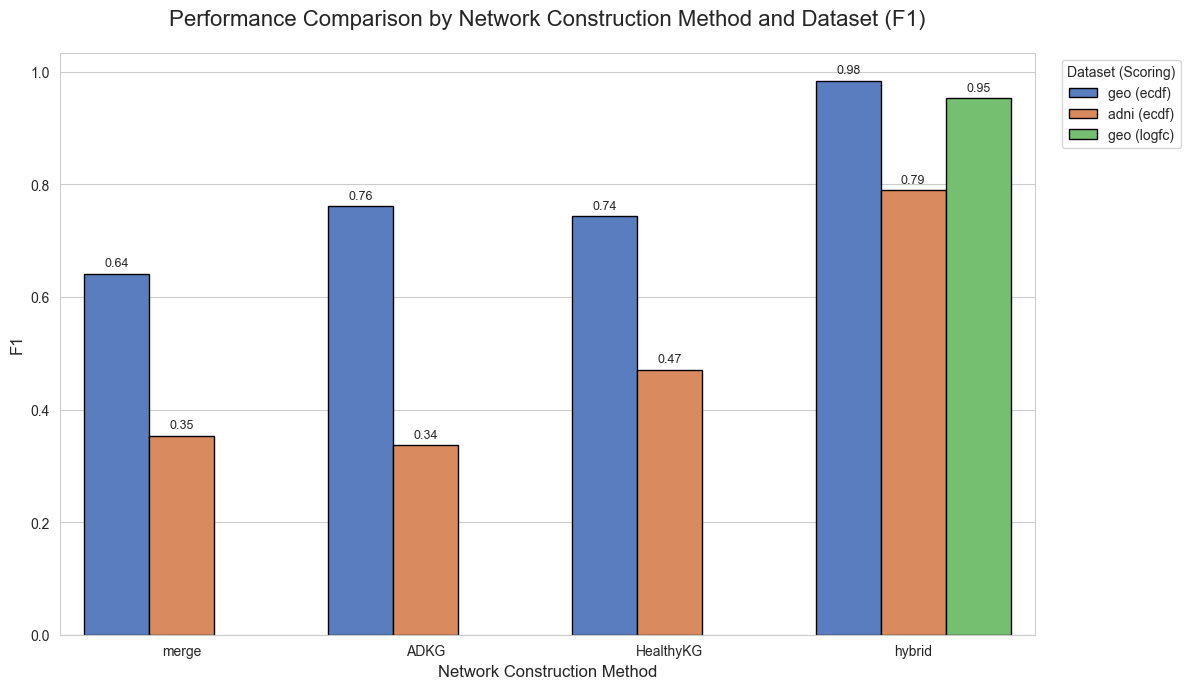

In [6]:
plot_grouped_performance(results_df, metric_name="F1")

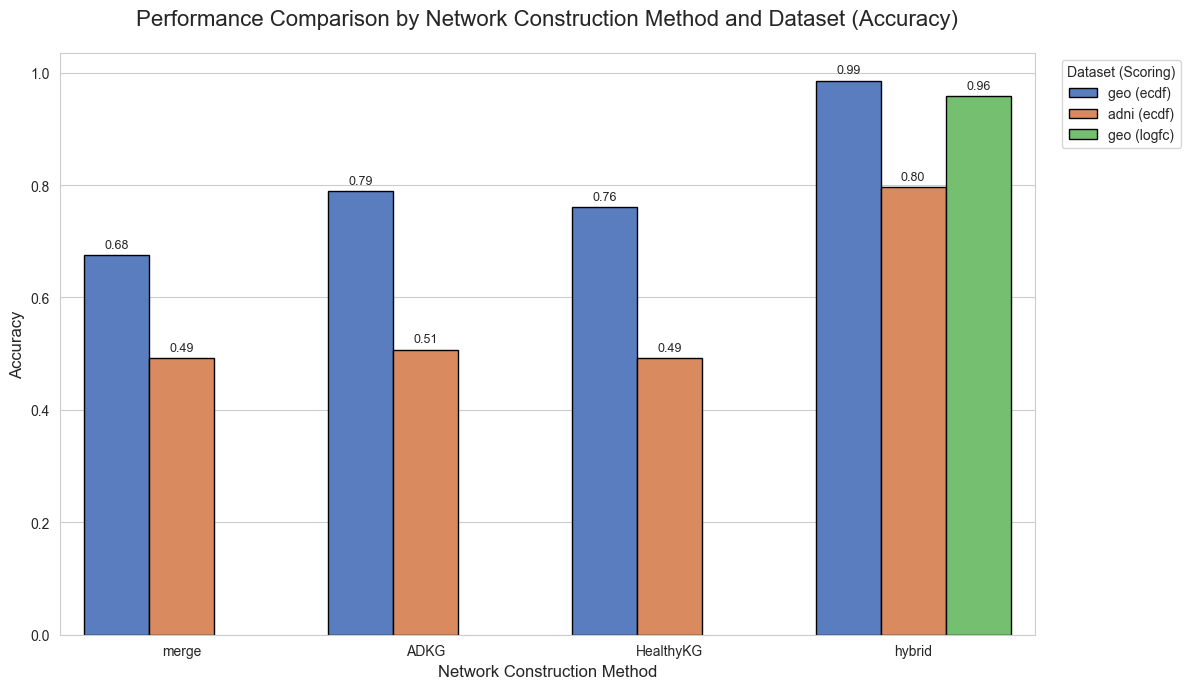

In [7]:
plot_grouped_performance(results_df, metric_name="Accuracy")

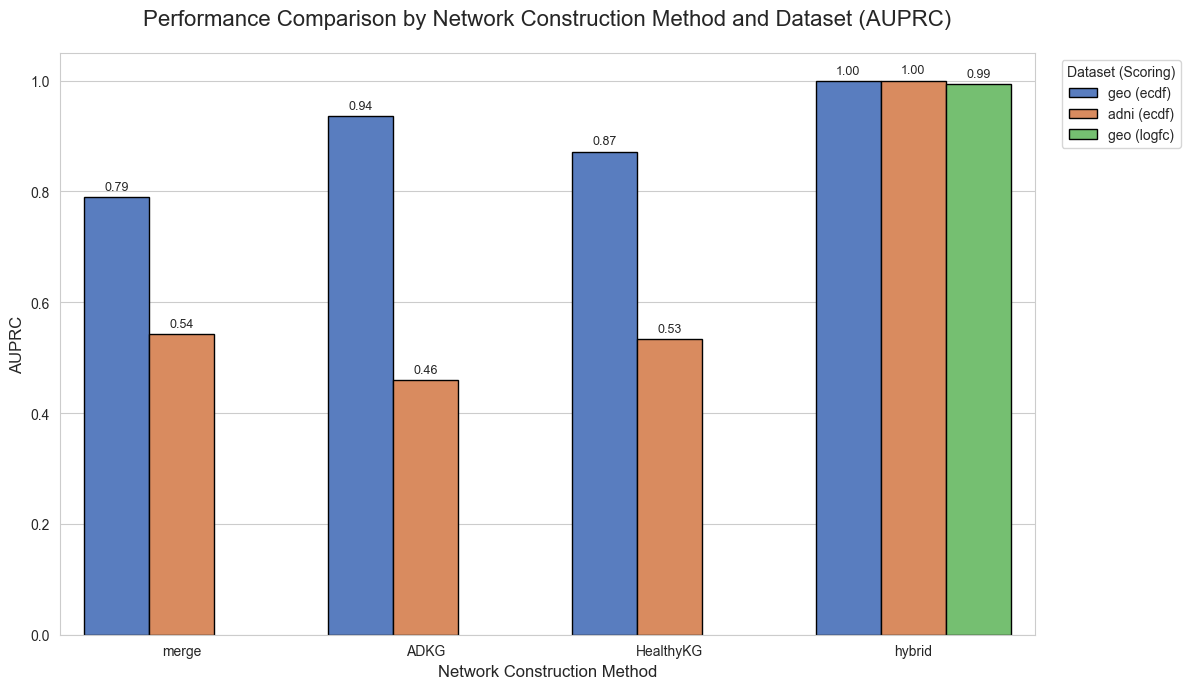

In [8]:
plot_grouped_performance(results_df, metric_name="AUPRC")

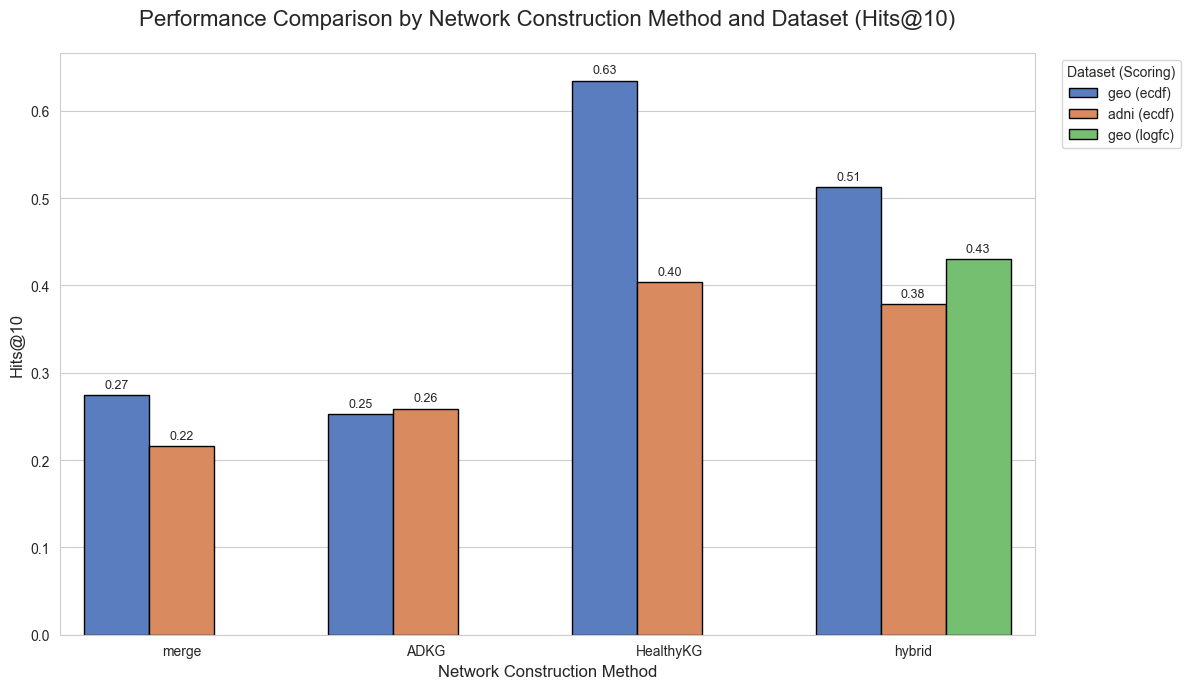

In [9]:
plot_grouped_performance(results_df, metric_name="Hits@10")